# DEEP-squared: visual walkthrough of the scattering fixes

**Original equations → corrected equations → effects on a scattering kernel.**

This notebook contains an executed, self-contained **NumPy reproduction** of
the original and corrected Monte Carlo routines. It needs only Python 3,
NumPy, and Matplotlib; no data downloads, MATLAB, or GPU are required.

The figures test the angular geometry and run a small scattering-only point-source
experiment. They do **not** establish that the MATLAB/GPU implementation has
passed its regression tests, reproduce the full DEEP-squared imaging pipeline,
or measure changes in reconstruction accuracy. The MATLAB test suite is supplied
separately at `fwd_model/tests/test_scattering.m`.

| Corrected file | Change |
|---|---|
| `f_launch.m` | Uniform **cosine** of polar angle for isotropic emission |
| `f_backProp.m` | Correct Snell refraction and objective acceptance cone |
| `f_spin.m` | Finite unit directions for isotropic, axial, and limiting cases |
| `f_hop.m` | Stable surface intersection; escaped photons remain stationary |
| `f_simPSFs3D.m` | Forward the requested `g`, `nt`, and `nm` |

Original revisions: DEEP-squared `068c1aa17ba294faad523f4942f2052276ef36b4`,
MC_LightScattering `7b0ed3d2a5c2c48178e7aa15591208b93294be26`.
The corrected MATLAB code is on
[Le0nZim/DEEP-squared](https://github.com/Le0nZim/DEEP-squared/tree/fix/monte-carlo-scattering-angles).


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm

SEED = 20260910
N_ANGULAR = 200_000
OLD = '#C35B37'
NEW = '#187F86'
INK = '#17324D'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 140, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelcolor': INK, 'text.color': INK,
    'axes.grid': False, 'figure.facecolor': 'white',
})
print('Seed:', SEED, '| NumPy:', np.__version__)


Seed: 20260910 | NumPy: 2.3.5


## 1. Isotropic emission: sample solid angle uniformly

The original source uses $\theta\sim U(0,\pi)$. This places too many photons near
the positive and negative optical axes. An isotropic source instead has
$\mu=\cos\theta\sim U(-1,1)$ because
$d\Omega=\sin\theta\,d\theta\,d\phi$.

An independent check is $E[u_x^2]=E[u_y^2]=E[u_z^2]=1/3$.
The original launch gives $(1/4,1/4,1/2)$.


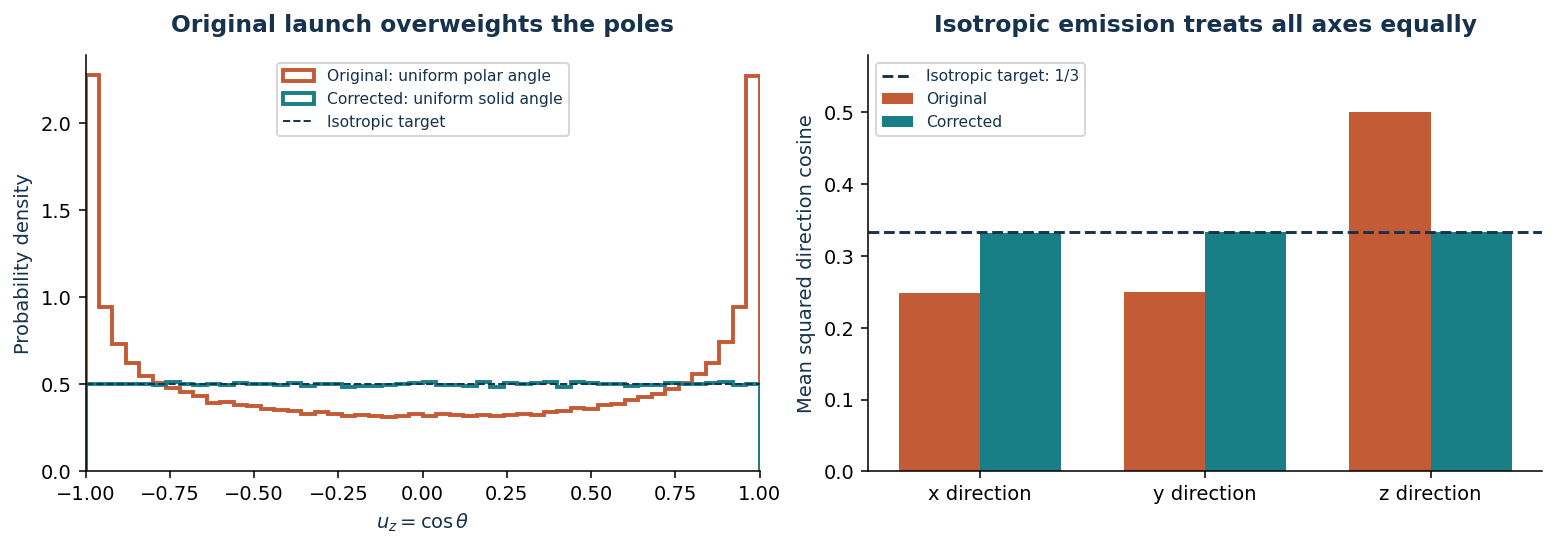

Original E[u_i^2]: [0.249118 0.25006  0.500822]
Corrected E[u_i^2]: [0.332518 0.33346  0.334022]


In [2]:
def launch(uniform, azimuth, corrected):
    z = 2*uniform-1 if corrected else np.cos(np.pi*uniform)
    transverse = np.sqrt(np.maximum(0, 1-z*z))
    return np.column_stack((transverse*np.cos(azimuth),
                            transverse*np.sin(azimuth), z))

rng = np.random.default_rng(SEED)
q = rng.random(N_ANGULAR)
phi = 2*np.pi*rng.random(N_ANGULAR)
u_old = launch(q, phi, False)
u_new = launch(q, phi, True)
mom_old = np.mean(u_old**2, axis=0)
mom_new = np.mean(u_new**2, axis=0)
assert np.max(np.abs(mom_new-1/3)) < 0.006

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
bins = np.linspace(-1, 1, 51)
ax[0].hist(u_old[:,2], bins=bins, density=True, histtype='step',
           linewidth=2, color=OLD, label='Original: uniform polar angle')
ax[0].hist(u_new[:,2], bins=bins, density=True, histtype='step',
           linewidth=2, color=NEW, label='Corrected: uniform solid angle')
ax[0].axhline(0.5, color=INK, linestyle='--', linewidth=1, label='Isotropic target')
ax[0].set(xlabel=r'$u_z = \cos\theta$', ylabel='Probability density',
          title='Original launch overweights the poles', xlim=(-1,1))
ax[0].legend(fontsize=8)
x = np.arange(3)
ax[1].bar(x-0.18, mom_old, width=0.36, color=OLD, label='Original')
ax[1].bar(x+0.18, mom_new, width=0.36, color=NEW, label='Corrected')
ax[1].axhline(1/3, color=INK, linestyle='--', label='Isotropic target: 1/3')
ax[1].set(xticks=x, xticklabels=['x direction','y direction','z direction'],
          ylabel='Mean squared direction cosine', ylim=(0,0.58),
          title='Isotropic emission treats all axes equally')
ax[1].legend(fontsize=8)
plt.show()
print('Original E[u_i^2]:', np.round(mom_old,6))
print('Corrected E[u_i^2]:', np.round(mom_new,6))


## 2. The objective filter selected the wrong directions

For a unit upward ray, $u_z=\cos\alpha$ and
$\sqrt{u_x^2+u_y^2}=\sin\alpha$, with $\alpha$ measured from the optical axis.
The acceptance condition is $n_m\sin\alpha\leq\mathrm{NA}$.

At **NA = 1, $n_t=n_m=1.33$**, the correct cone is **0°–48.75°**.
The original filter instead selects approximately **41.25°–90°**.
The disks below show **direction cosines**, not positions in a physical pupil.


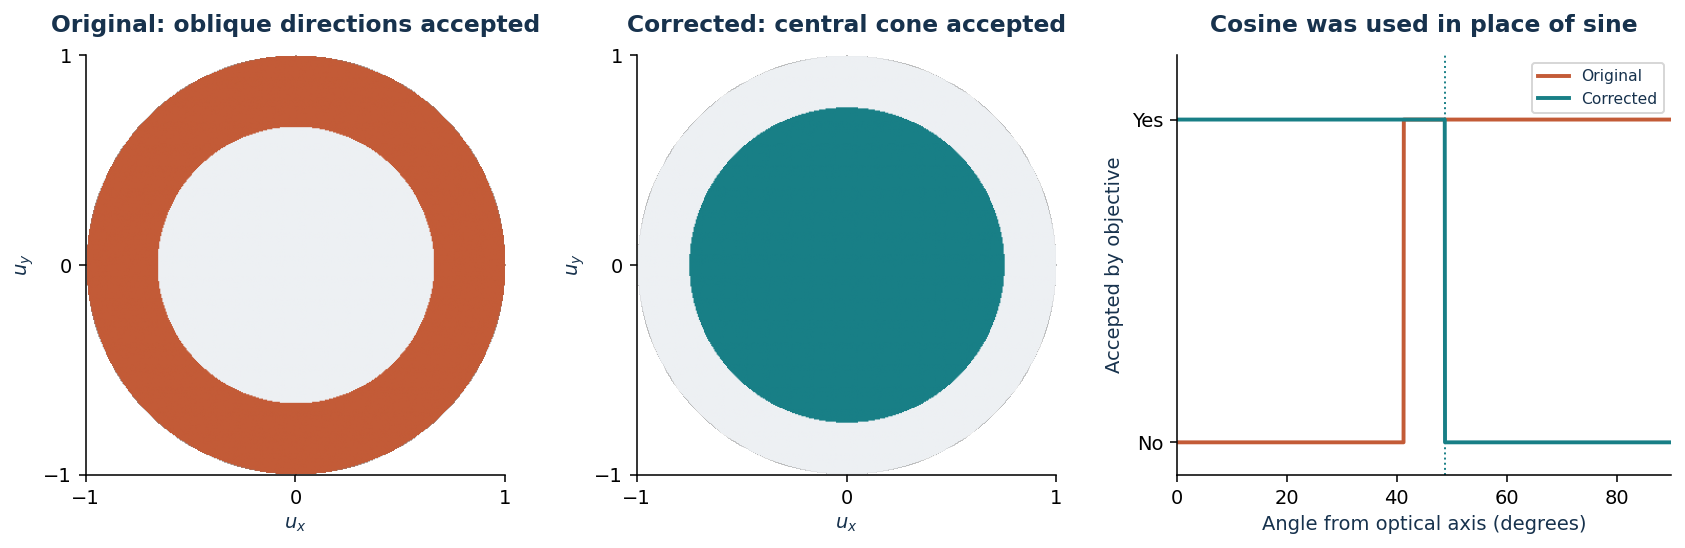

Correct cone: 0 to 48.753 degrees
Original acceptance band: 41.247 to 90 degrees
Ballistic collection, fraction of ALL isotropic launches: 17.1030%; analytical target 17.0350%


In [3]:
NA, NM = 1.0, 1.33
ratio = NA/NM
alpha_max = np.degrees(np.arcsin(ratio))
alpha_old_min = np.degrees(np.arccos(ratio))
v = np.linspace(-1,1,401)
X, Y = np.meshgrid(v,v)
r2 = X*X+Y*Y
up_disk = r2 <= 1
UZ = np.sqrt(np.maximum(0,1-r2))
old_mask = up_disk & (UZ <= ratio)
new_mask = up_disk & (r2 <= ratio*ratio)
cmap_old = ListedColormap(['#EDF0F3', OLD])
cmap_new = ListedColormap(['#EDF0F3', NEW])

fig, ax = plt.subplots(1,3,figsize=(12,3.8),layout='constrained')
for a, mask, cmap, title in zip(ax[:2], [old_mask,new_mask],
                               [cmap_old,cmap_new],
                               ['Original: oblique directions accepted',
                                'Corrected: central cone accepted']):
    field = np.ma.masked_where(~up_disk, mask.astype(float))
    a.imshow(field, origin='lower', extent=(-1,1,-1,1), cmap=cmap, vmin=0,vmax=1)
    a.set(xlabel=r'$u_x$', ylabel=r'$u_y$', title=title, aspect='equal')
    a.set_xticks([-1,0,1]); a.set_yticks([-1,0,1])
angles = np.linspace(0,89.99,1800)
a = np.deg2rad(angles)
ax[2].plot(angles, (np.cos(a)<=ratio).astype(float), color=OLD, linewidth=2,label='Original')
ax[2].plot(angles, (np.sin(a)<=ratio).astype(float), color=NEW, linewidth=2,label='Corrected')
ax[2].axvline(alpha_max, color=NEW, linestyle=':', linewidth=1)
ax[2].set(xlabel='Angle from optical axis (degrees)', ylabel='Accepted by objective',
          yticks=[0,1], yticklabels=['No','Yes'], ylim=(-0.1,1.2), xlim=(0,90),
          title='Cosine was used in place of sine')
ax[2].legend(loc='upper right',fontsize=8)
plt.show()

ballistic_target = (1-np.sqrt(1-ratio**2))/2
ballistic_measured = np.mean((u_new[:,2]>0) &
                            (np.linalg.norm(u_new[:,:2],axis=1)<=ratio))
assert abs(ballistic_measured-ballistic_target) < 0.006
print(f'Correct cone: 0 to {alpha_max:.3f} degrees')
print(f'Original acceptance band: {alpha_old_min:.3f} to 90 degrees')
print(f'Ballistic collection, fraction of ALL isotropic launches: '
      f'{ballistic_measured:.4%}; analytical target {ballistic_target:.4%}')


## 3. Refraction: the same sine/cosine confusion changes transmission

Snell's law is $n_t\sin\alpha_t=n_m\sin\alpha_m$.
For normalized incident directions, the correction uses
$u_{x,m}=(n_t/n_m)u_{x,t}$, $u_{y,m}=(n_t/n_m)u_{y,t}$, and
$u_{z,m}=\sqrt{1-u_{x,m}^2-u_{y,m}^2}$.

This example deliberately uses **$n_t=1.5$, $n_m=1$** to expose the error;
the supplied model defaults use matched indices. A **30° ray must transmit at
48.59°**, whereas a **50° ray must internally reflect**. The original routine
reverses those classifications. We call the collection geometry directly here,
independently of the separate parameter-forwarding bug.


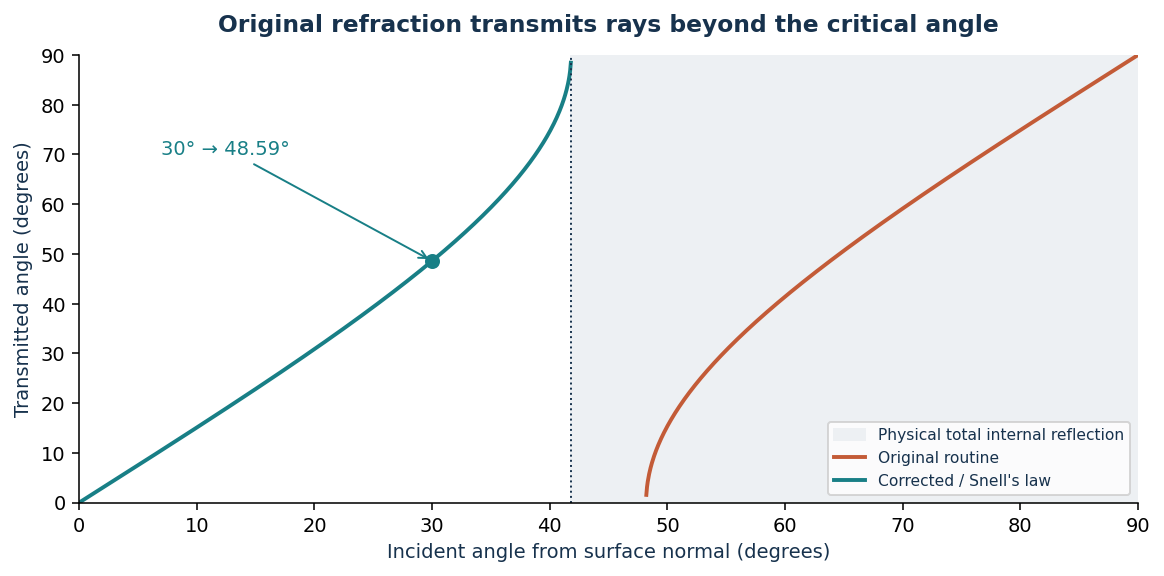

In [4]:
def refract(directions, nt, nm, corrected):
    norm2 = np.sum(directions*directions,axis=1)
    ux, uy, uz = directions.T
    with np.errstate(divide='ignore',invalid='ignore'):
        if corrected:
            transverse = (nt/nm)*directions[:,:2]/np.sqrt(norm2)[:,None]
            sin2 = np.sum(transverse**2,axis=1)
            keep = (uz>0) & (norm2>0) & np.isfinite(norm2) & (sin2<1)
            outgoing = np.column_stack((transverse[keep], np.sqrt(1-sin2[keep])))
        else:
            sin2 = (nt/nm)**2 * uz**2 * norm2
            new_uz2 = (ux**2+uy**2)*sin2/(1-sin2)
            keep = new_uz2 >= 0
            outgoing = directions[keep].copy()
            outgoing[:,2] = np.sqrt(new_uz2[keep])
    return outgoing, np.flatnonzero(keep)

incident = np.linspace(0.05,89.95,1500)
a = np.deg2rad(incident)
rays = np.column_stack((np.sin(a),np.zeros_like(a),np.cos(a)))
critical = np.degrees(np.arcsin(1/1.5))
fig, ax = plt.subplots(figsize=(8.2,4),layout='constrained')
ax.axvspan(critical,90,color='#EDF0F3',label='Physical total internal reflection')
for corrected, color, name in [(False,OLD,'Original routine'),(True,NEW,"Corrected / Snell's law")]:
    outgoing, ids = refract(rays,1.5,1.0,corrected)
    transmitted = np.degrees(np.arctan2(np.linalg.norm(outgoing[:,:2],axis=1),outgoing[:,2]))
    ax.plot(incident[ids],transmitted,color=color,linewidth=2,label=name)
ax.scatter([30],[np.degrees(np.arcsin(0.75))],color=NEW,s=45,zorder=5)
ax.annotate('30° → 48.59°',xy=(30,np.degrees(np.arcsin(0.75))),xytext=(7,70),
            arrowprops={'arrowstyle':'->','color':NEW},color=NEW)
ax.axvline(critical,color=INK,linestyle=':',linewidth=1)
ax.set(xlabel='Incident angle from surface normal (degrees)',
       ylabel='Transmitted angle (degrees)', xlim=(0,90), ylim=(0,90),
       title='Original refraction transmits rays beyond the critical angle')
ax.legend(fontsize=8,loc='lower right')
plt.show()

case_angles = np.deg2rad([0,30,50])
case_rays = np.column_stack((np.sin(case_angles),np.zeros(3),np.cos(case_angles)))
transmitted, ids = refract(case_rays,1.5,1.0,True)
assert np.array_equal(ids,[0,1])
assert np.isclose(np.degrees(np.arctan2(transmitted[1,0],transmitted[1,2])),48.59037789072914)


## 4. HG scattering is correct in the ordinary case; edge cases were unstable

The scattering angle is measured **relative to the incoming direction**, which
is different from the angle used by the objective filter. The ordinary
Henyey–Greenstein inverse CDF is retained. It must satisfy
$E[\cos\theta]=g$ and $E[P_2(\cos\theta)]=g^2$.

The fixes handle $g=0$, exactly axial incidence, small-$g$ cancellation,
and the limits $g=\pm1$. Near an axis, the stable transverse norm avoids
subtracting almost equal numbers in $\sqrt{1-u_z^2}$.


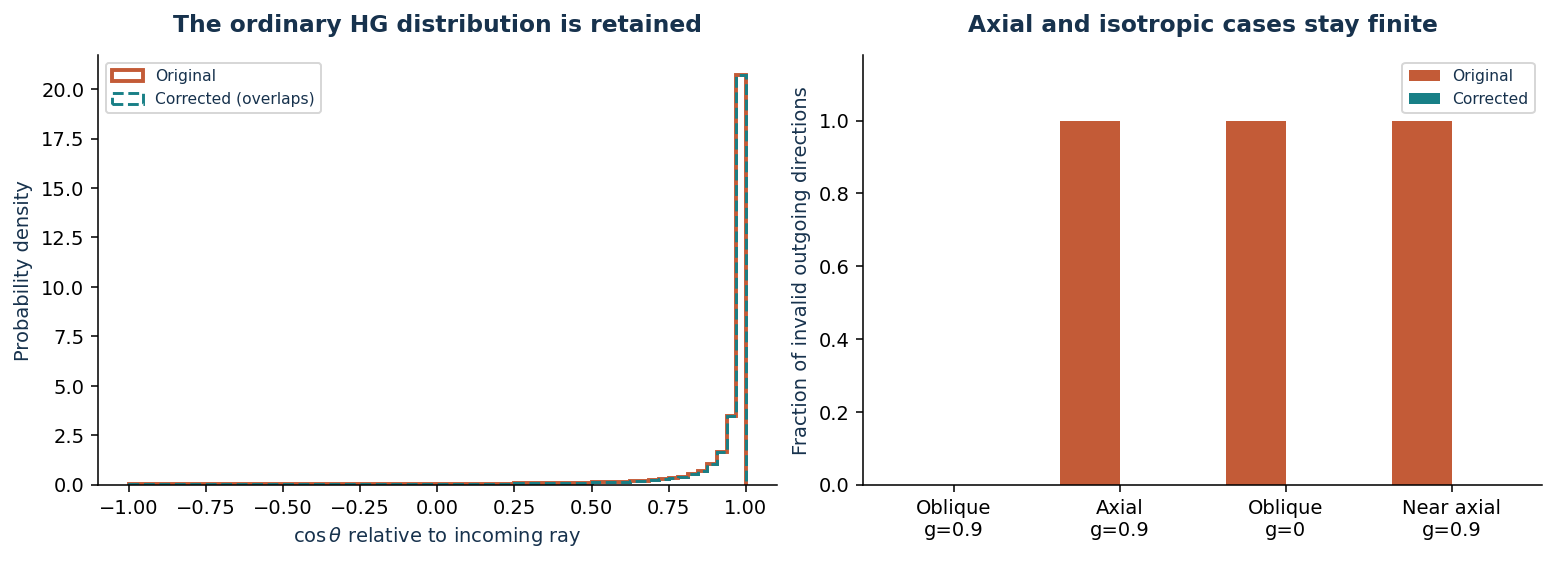

HG mean cos(theta): 0.900510; target 0.9
HG mean P2: 0.810952; target 0.81


In [5]:
def spin(directions, g, rnd1, rnd2, corrected):
    ux, uy, uz = directions.T
    with np.errstate(divide='ignore',invalid='ignore'):
        if corrected and g == 0:
            ct = 2*rnd1-1
        elif corrected and abs(g) == 1:
            ct = np.full_like(rnd1,g)
        elif corrected and abs(g) < 1e-3:
            q = 2*rnd1-1
            ct = (2*q+g*(q*q+3)+2*g*g*q+g**3*(q*q-1))/(2*(1+g*q)**2)
        else:
            temp = (1-g*g)/(1-g+2*g*rnd1)
            ct = (1+g*g-temp*temp)/(2*g)
        if corrected:
            ct = np.clip(ct,-1,1)
        st = np.sqrt(np.maximum(0,1-ct*ct) if corrected else 1-ct*ct)
        psi = 2*np.pi*rnd2
        cp, sp = np.cos(psi), np.sin(psi)
        transverse = np.hypot(ux,uy) if corrected else np.sqrt(1-uz*uz)
        denominator = transverse.copy()
        axial = transverse == 0
        if corrected:
            denominator[axial] = 1
        out = np.column_stack((
            st*(ux*uz*cp-uy*sp)/denominator + ux*ct,
            st*(uy*uz*cp+ux*sp)/denominator + uy*ct,
            -st*cp*transverse + uz*ct))
        if corrected:
            out[axial] = np.column_stack((st[axial]*cp[axial],st[axial]*sp[axial],
                                         np.sign(uz[axial])*ct[axial]))
            out /= np.linalg.norm(out,axis=1)[:,None]
    return out

rng = np.random.default_rng(SEED+1)
r1, r2 = rng.random(N_ANGULAR), rng.random(N_ANGULAR)
incoming = np.tile([0.6,0,0.8],(N_ANGULAR,1))
v_old = spin(incoming,0.9,r1,r2,False)
v_new = spin(incoming,0.9,r1,r2,True)
ct_old = np.sum(incoming*v_old,axis=1)
ct_new = np.sum(incoming*v_new,axis=1)
assert abs(ct_new.mean()-0.9) < 0.006
assert abs(np.mean((3*ct_new**2-1)/2)-0.81) < 0.006
assert np.max(np.abs(ct_old-ct_new)) < 1e-12

cases = [('Oblique, g=0.9',[0.6,0,0.8],0.9),
         ('Axial, g=0.9',[0,0,1],0.9),
         ('Oblique, g=0',[0.6,0,0.8],0),
         ('Near axial, g=0.9',[1e-12,0,1],0.9)]
invalid = np.zeros((len(cases),2))
for i, (_, direction, g) in enumerate(cases):
    src = np.tile(direction,(4000,1))
    for j, corrected in enumerate([False,True]):
        out = spin(src,g,r1[:4000],r2[:4000],corrected)
        invalid[i,j] = np.mean(~np.all(np.isfinite(out),axis=1))
assert np.all(invalid[:,1] == 0)

fig, ax = plt.subplots(1,2,figsize=(11,3.9),layout='constrained')
edges = np.linspace(-1,1,65)
ax[0].hist(ct_old,bins=edges,density=True,histtype='step',color=OLD,linewidth=2,label='Original')
ax[0].hist(ct_new,bins=edges,density=True,histtype='step',color=NEW,linewidth=1.5,
           linestyle='--',label='Corrected (overlaps)')
ax[0].set(xlabel=r'$\cos\theta$ relative to incoming ray',ylabel='Probability density',
          title='The ordinary HG distribution is retained')
ax[0].legend(fontsize=8)
x = np.arange(len(cases))
ax[1].bar(x-0.18,invalid[:,0],width=0.36,color=OLD,label='Original')
ax[1].bar(x+0.18,invalid[:,1],width=0.36,color=NEW,label='Corrected')
ax[1].set(xticks=x,xticklabels=[c[0].replace(', ','\n') for c in cases],
          ylim=(0,1.18),ylabel='Fraction of invalid outgoing directions',
          title='Axial and isotropic cases stay finite')
ax[1].legend(fontsize=8)
plt.show()
print(f'HG mean cos(theta): {ct_new.mean():.6f}; target 0.9')
print(f'HG mean P2: {np.mean((3*ct_new**2-1)/2):.6f}; target 0.81')


## 5. A small tissue-scattering experiment

The following code reproduces the hop/spin/collection equations in NumPy.
The original and corrected runs use the **same random-number seed** and the
same random draws per photon and hop. Photon launch and surface collection
are then crossed to separate their effects.

**Configuration:** a point source 350 µm below a homogeneous surface,
$\mu_s=200\ \mathrm{cm}^{-1}$ (mean free path 50 µm), $g=0.9$,
$n_t=n_m=1.33$, NA = 1. These optical parameters and depth match the supplied
defaults. This quick diagnostic uses **40,000 photons and 300 hops**, rather
than the much larger production run. The finite hop budget is not a
convergence study; unescaped photons remain uncollected.

The displayed field of view is deliberately broad (±500 µm with coarse bins)
to reveal scattering tails. It differs from the production pixel grid.
There is no excitation PSF, emission PSF, DMD pattern, detector noise, or
reconstruction network here.


In [6]:
N_PHOTONS = 40_000
N_HOPS = 300
MUS = 200.0                  # cm^-1
MEAN_FREE_PATH = 1e4/MUS     # micrometers
DEPTH = -7*MEAN_FREE_PATH    # micrometers
G = 0.9
NT = NM = 1.33
NA = 1.0

def transport(corrected):
    rng = np.random.default_rng(SEED+2)
    directions = launch(rng.random(N_PHOTONS),2*np.pi*rng.random(N_PHOTONS),corrected)
    positions = np.zeros((N_PHOTONS,3))
    positions[:,2] = DEPTH
    pathlength = np.zeros(N_PHOTONS)
    for _ in range(N_HOPS):
        s = -np.log(rng.random(N_PHOTONS))*MEAN_FREE_PATH
        at_surface = positions[:,2]+s*directions[:,2] >= 0
        if corrected:
            at_surface &= directions[:,2]>0
        distance = -positions[at_surface,2]/directions[at_surface,2]
        s[at_surface] = np.maximum(0,distance) if corrected else distance
        positions += s[:,None]*directions
        if corrected:
            positions[at_surface,2] = 0
        pathlength += s
        spun = spin(directions,G,rng.random(N_PHOTONS),rng.random(N_PHOTONS),corrected)
        directions[~at_surface] = spun[~at_surface]
    assert np.all(np.isfinite(positions)) and np.all(np.isfinite(directions))
    assert np.max(np.abs(np.linalg.norm(directions,axis=1)-1)) < 1e-8
    return positions[at_surface], directions[at_surface], float(at_surface.mean())

def collect(positions,directions,corrected):
    outgoing, ids = refract(directions,NT,NM,corrected)
    norm = np.linalg.norm(outgoing,axis=1)
    with np.errstate(divide='ignore',invalid='ignore'):
        aperture_quantity = (np.linalg.norm(outgoing[:,:2],axis=1) if corrected
                             else outgoing[:,2]/norm)
    in_aperture = aperture_quantity <= NA/NM
    outgoing = outgoing[in_aperture]
    selected = positions[ids[in_aperture]]
    step = ((DEPTH-selected[:,2]) if corrected else DEPTH)/outgoing[:,2]
    projected = selected + step[:,None]*outgoing
    assert np.all(np.isfinite(projected))
    return projected[:,:2]

started = time.perf_counter()
old_pos, old_dir, old_escape = transport(False)
new_pos, new_dir, new_escape = transport(True)
clouds = {
    'Original transport + original collection': collect(old_pos,old_dir,False),
    'Original transport + corrected collection': collect(old_pos,old_dir,True),
    'Corrected transport + original collection': collect(new_pos,new_dir,False),
    'Corrected transport + corrected collection': collect(new_pos,new_dir,True),
}
print(f'Two {N_PHOTONS:,}-photon runs, {N_HOPS} hops: {time.perf_counter()-started:.1f} seconds')
print(f'Escaped by final hop: original {old_escape:.2%}; corrected {new_escape:.2%}')
for name, xy in clouds.items():
    print(f'{name}: {len(xy)/N_PHOTONS:.3%} of launched photons collected')


Two 40,000-photon runs, 300 hops: 3.0 seconds
Escaped by final hop: original 75.53%; corrected 75.66%
Original transport + original collection: 37.163% of launched photons collected
Original transport + corrected collection: 48.695% of launched photons collected
Corrected transport + original collection: 37.867% of launched photons collected
Corrected transport + corrected collection: 48.220% of launched photons collected


### Scattering kernels: one shared absolute scale

Each map is a histogram of backprojected photons divided by **all launched
photons**. All four panels use the **same logarithmic color scale** and spatial
bins. The maps are not separately normalized or smoothed. Color therefore
retains differences in collection efficiency as well as spatial spread.

Rows switch the launch/transport implementation; columns switch refraction and
objective selection on the same recorded surface rays. The upper-left panel
is the original reproduction; the lower-right panel uses all corrections.


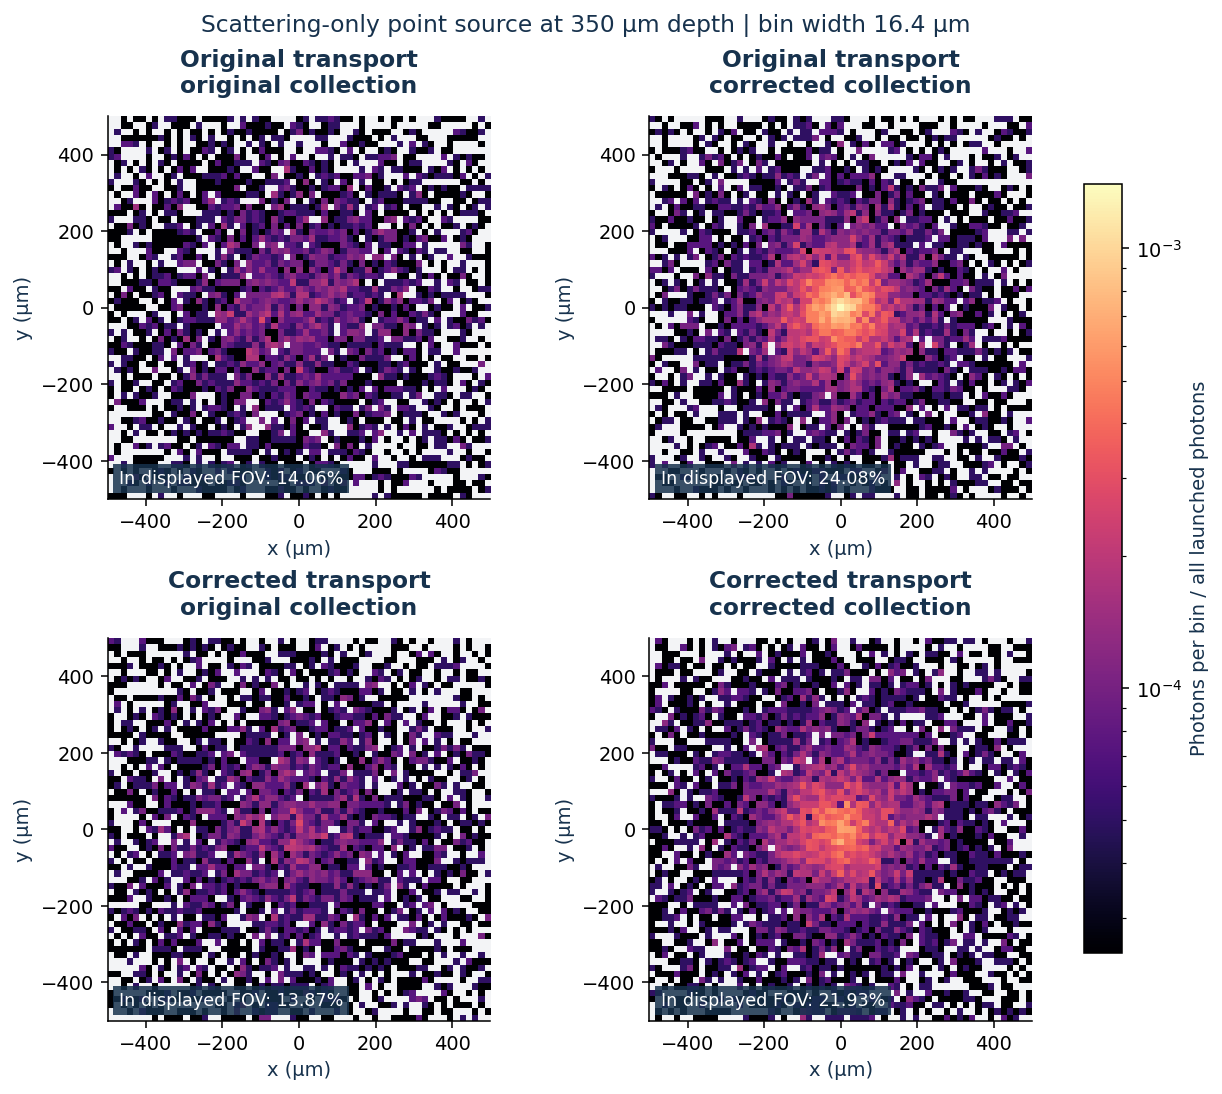

In [7]:
HALF_WIDTH = 500.0
EDGES = np.linspace(-HALF_WIDTH,HALF_WIDTH,62)
BIN_WIDTH = np.diff(EDGES)[0]
kernels = {name: np.histogram2d(xy[:,0],xy[:,1],bins=(EDGES,EDGES))[0].T/N_PHOTONS
           for name,xy in clouds.items()}
vmax = max(k.max() for k in kernels.values())
norm = LogNorm(vmin=1/N_PHOTONS,vmax=vmax)
cmap = plt.colormaps['magma'].copy()
cmap.set_bad('#F3F4F6')
fig, axes = plt.subplots(2,2,figsize=(9,7.7),layout='constrained')
for ax, (name,kernel) in zip(axes.flat,kernels.items()):
    im = ax.imshow(np.ma.masked_equal(kernel,0),origin='lower',
                   extent=(-HALF_WIDTH,HALF_WIDTH,-HALF_WIDTH,HALF_WIDTH),
                   cmap=cmap,norm=norm,interpolation='nearest')
    ax.set(title=name.replace(' + ','\n'),xlabel='x (µm)',ylabel='y (µm)',aspect='equal')
    ax.text(0.03,0.04,f'In displayed FOV: {kernel.sum():.2%}',transform=ax.transAxes,
            fontsize=9,color='white',bbox={'facecolor':'#17324D','alpha':0.85,'edgecolor':'none','pad':3})
fig.colorbar(im,ax=axes.ravel().tolist(),label='Photons per bin / all launched photons',shrink=0.85)
fig.suptitle(f'Scattering-only point source at {abs(DEPTH):.0f} µm depth | bin width {BIN_WIDTH:.1f} µm',fontsize=12)
plt.show()


### Separate collection efficiency from blur

The left plot uses **all collected photons**, including those outside the maps,
and shows their conditional radial distribution. It describes spatial spread
after conditioning on collection. The right plot uses **all launched photons**
as its denominator and preserves absolute collection losses. This distinction
avoids treating a narrower normalized kernel as evidence of higher throughput.


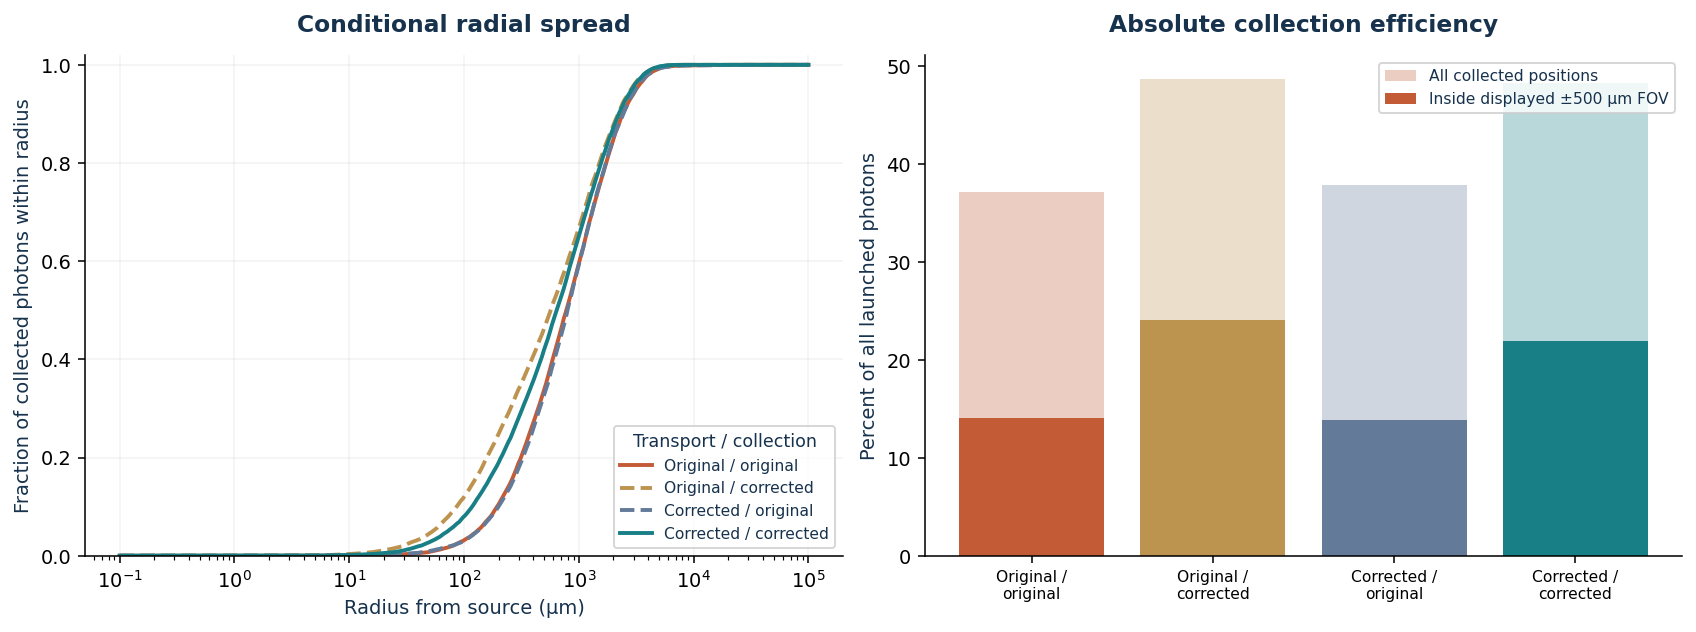

Original transport + original collection
  collected: 37.163%; in displayed FOV: 14.065%
  conditional median radius: 776.8 µm; 90th percentile: 2403.9 µm
Corrected transport + corrected collection
  collected: 48.220%; in displayed FOV: 21.930%
  conditional median radius: 641.4 µm; 90th percentile: 2229.3 µm


In [8]:
names = list(clouds)
styles = [(OLD,'-'),('#BD9350','--'),('#637A99','--'),(NEW,'-')]
radii = {name:np.linalg.norm(xy,axis=1) for name,xy in clouds.items()}
radius_grid = np.geomspace(0.1,100_000,350)
labels = ['Original / original','Original / corrected','Corrected / original','Corrected / corrected']
fig, ax = plt.subplots(1,2,figsize=(12,4.4),layout='constrained')
for name,label,(color,style) in zip(names,labels,styles):
    r = np.sort(radii[name])
    cdf = np.searchsorted(r,radius_grid,side='right')/len(r)
    ax[0].semilogx(radius_grid,cdf,color=color,linestyle=style,linewidth=2,label=label)
ax[0].set(xlabel='Radius from source (µm)',ylabel='Fraction of collected photons within radius',
          ylim=(0,1.02),title='Conditional radial spread')
ax[0].legend(title='Transport / collection',fontsize=8,title_fontsize=9,loc='lower right')
ax[0].grid(alpha=0.15)
x = np.arange(4)
all_collected = np.array([len(clouds[n])/N_PHOTONS for n in names])
in_fov = np.array([kernels[n].sum() for n in names])
ax[1].bar(x,100*all_collected,color=[s[0] for s in styles],alpha=0.3,label='All collected positions')
ax[1].bar(x,100*in_fov,color=[s[0] for s in styles],label='Inside displayed ±500 µm FOV')
ax[1].set(xticks=x,xticklabels=[s.replace(' / ',' /\n') for s in labels],
          ylabel='Percent of all launched photons',title='Absolute collection efficiency')
ax[1].tick_params(axis='x',labelsize=8)
ax[1].legend(fontsize=8)
plt.show()

for name in [names[0],names[-1]]:
    r = radii[name]
    print(name)
    print(f'  collected: {len(r)/N_PHOTONS:.3%}; in displayed FOV: {kernels[name].sum():.3%}')
    print(f'  conditional median radius: {np.median(r):.1f} µm; 90th percentile: {np.quantile(r,0.9):.1f} µm')
assert np.all(in_fov <= all_collected+1e-12)


## 6. Parameter forwarding and surface stability

The upstream wrapper initializes a separate Monte Carlo parameter structure.
It copied `mus` but omitted `g`, `nt`, and `nm`, so edits to those three
forward-model inputs were ignored. The correction explicitly copies all three.

| Example requested input | Original effective input | Corrected effective input |
|---|---|---|
| `g = 0.5` | `g = 0.9` | `g = 0.5` |
| `nt = 1.5` | `nt = 1.33` | `nt = 1.5` |
| `nm = 1.0` | `nm = 1.33` | `nm = 1.0` |

The surface fix sets escaped `z` exactly to zero and prevents a negative
boundary step caused by tiny floating-point excursions. It is a numerical
stability correction, not a new tissue-scattering law. The following checks
cover these edge cases in this NumPy reproduction; the actual MATLAB tests
remain a separate gate.


In [9]:
edge_directions = np.array([[0,0,1],[0,0,-1],[0.6,0,0.8],[0,1,0]],dtype=float)
rng = np.random.default_rng(SEED+3)
for g in [-1,0,1e-10,0.9,1]:
    out = spin(edge_directions,g,rng.random(4),rng.random(4),True)
    assert np.all(np.isfinite(out))
    assert np.allclose(np.sum(out*out,axis=1),1)
    if abs(g)==1:
        assert np.allclose(out,g*edge_directions)
tiny_positive_z = np.finfo(float).eps
old_boundary_step = -tiny_positive_z/0.8
new_boundary_step = max(0,old_boundary_step)
assert old_boundary_step < 0 and new_boundary_step == 0
print('PASS: NumPy edge-case directions are finite and normalized.')
print('PASS: a tiny positive surface excursion no longer causes a negative step.')
print('PASS: angular, Snell, HG, and histogram-accounting assertions above.')
print('MATLAB/GPU validation: not performed by this notebook.')


PASS: NumPy edge-case directions are finite and normalized.
PASS: a tiny positive surface excursion no longer causes a negative step.
PASS: angular, Snell, HG, and histogram-accounting assertions above.
MATLAB/GPU validation: not performed by this notebook.


## Interpretation and next steps

- The **launch bias** and **objective acceptance error** change the default
  model. The notebook isolates them and shows their effect on a scattering PSF.
- The **ordinary HG phase law is correct**; its limiting and axial cases needed
  numerical fixes. Those fixes are not evidence that a different tissue phase
  function should be used.
- The refraction correction fixes first-pass transmission geometry. The model
  still does not return internally reflected rays to the tissue or apply
  Fresnel transmission weights. The tissue experiment above uses matched
  indices, where that particular interface issue is absent.
- Results above are one finite, seeded NumPy experiment. Increase photon count
  and hop budget and check convergence before using quantitative kernel widths
  or collection efficiencies. Neither visual differences nor these numerical
  assertions establish improved reconstruction accuracy.
- Before regenerating production data, run the actual MATLAB tests from the
  repository root:

```matlab
results = runtests('fwd_model/tests/test_scattering.m');
assertSuccess(results);
```

Then regenerate the saved scattering PSFs and affected synthetic measurements.
Existing `.mat` files and trained weights do not change automatically.

### Sources

- [Pinned original Monte Carlo source](https://github.com/dushanw/MC_LightScattering/tree/7b0ed3d2a5c2c48178e7aa15591208b93294be26)
- [Pinned DEEP-squared wrapper](https://github.com/wadduwagelab/DEEP-squared/blob/068c1aa17ba294faad523f4942f2052276ef36b4/fwd_model/f_simPSFs3D.m)
- [OMLC MCML: HG sampling, axial directions, and refraction](https://omlc.org/software/mc/mcml/mcml-src/mcmlgo.c)
- [OMLC mc321.c: isotropic point-source launch](https://omlc.org/software/mc/mc321.c)
- [Nikon MicroscopyU: numerical aperture](https://www.microscopyu.com/microscopy-basics/numerical-aperture)
